In [23]:
import os 
import pandas as pd

In [24]:
import glob

In [41]:
log_paths = glob.glob('../logs/exp1d/fno1d/lnabs/*.csv')

In [42]:
log_info

'fno1d-m16-w64-4096-4096-cl0-mlx-seed8.csv'

In [43]:
log_df = pd.DataFrame(columns=('model', 'dataset', 'coarse_level', 'resolution', 'residual', 'seed', 'test_l2'))
for i, log_path in enumerate(log_paths):
    dataset, log_info = log_path.split('/')[-2:]
    model_nm, _, _, trares, testres, clevel, mlevel, seed = log_info.split('.')[0].split('-')
    clevel = int(clevel[2:])
    trares = int(trares)
    testres = int(testres)
    seed = int(seed[4:])
    log = pd.read_csv(log_path)
    mlevel = int(mlevel[2:]) if mlevel[2:] != 'x' else -1
    best_l2 = log.test_l2.min()
    log_df.loc[i] = [model_nm, dataset, clevel, trares, mlevel, seed, best_l2]

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns 

#### test relative L2 error without coarsen on 1024

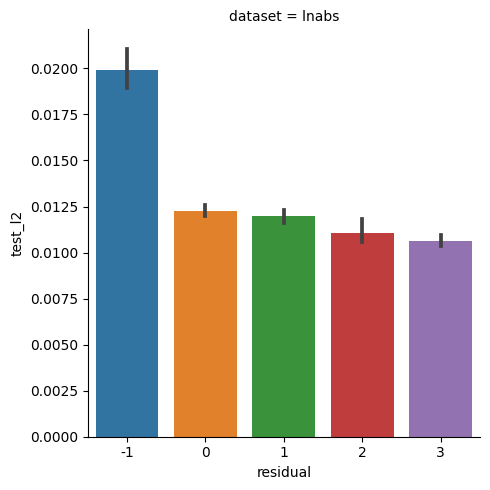

In [45]:
sub_df = log_df[(log_df.coarse_level == 0)  & (log_df.resolution == 4096)]
sns.catplot(data=sub_df, x='residual', y='test_l2', kind='bar', col='dataset')

#### test relative L2 error with coarsen on 1024

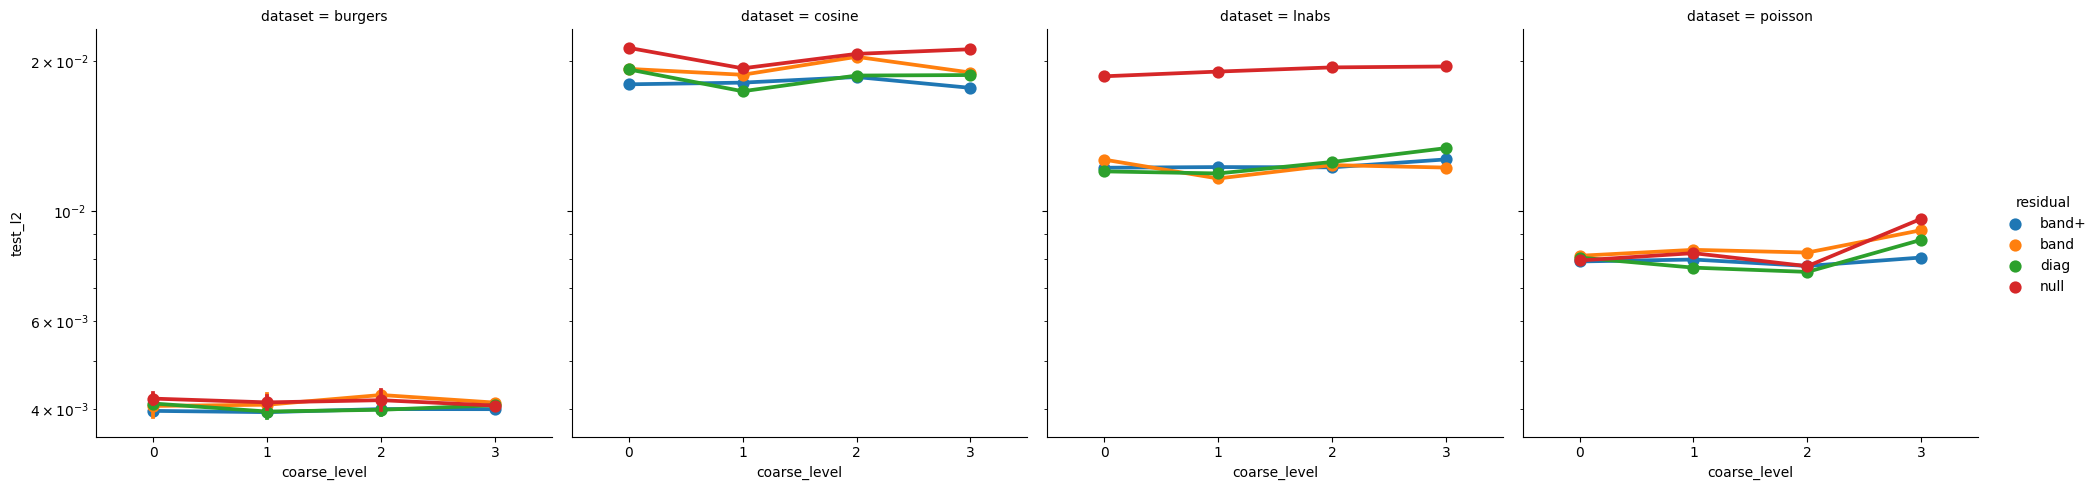

In [26]:
sub_df = log_df[ (log_df.resolution == 8192)]
sns.catplot(data=sub_df, x='coarse_level', y='test_l2', kind='point', col='dataset', hue='residual')
plt.yscale('log')